# 📊 TASK : Sales Prediction using Python (Advanced)

In this notebook, we will use the **Advertising.csv** dataset to perform the following tasks:

1. Data cleaning & exploration
2. Feature engineering
3. Train multiple models (**Linear Regression → Random Forest → Gradient Boosting**)
4. Make the model **advanced** using hyperparameter tuning
5. Extract **feature importance/weightage** (to determine which advertising channel has the greatest impact on sales)
6. Generate business insights




## 1️⃣ Setup — Libraries Install & Import

In [1]:

!pip install xgboost -q


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 2️⃣ Dataset Upload / Load

In [3]:

from google.colab import files
uploaded = files.upload()


Saving Advertising.csv to Advertising.csv


In [4]:

df = pd.read_csv("Advertising.csv", index_col=0)
df.head()


,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


## 3️⃣ Data Cleaning

In [5]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe()


Shape: (200, 4)

Data types:
 TV           float64
Radio        float64
Newspaper    float64
Sales        float64
dtype: object

Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate rows: 0


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


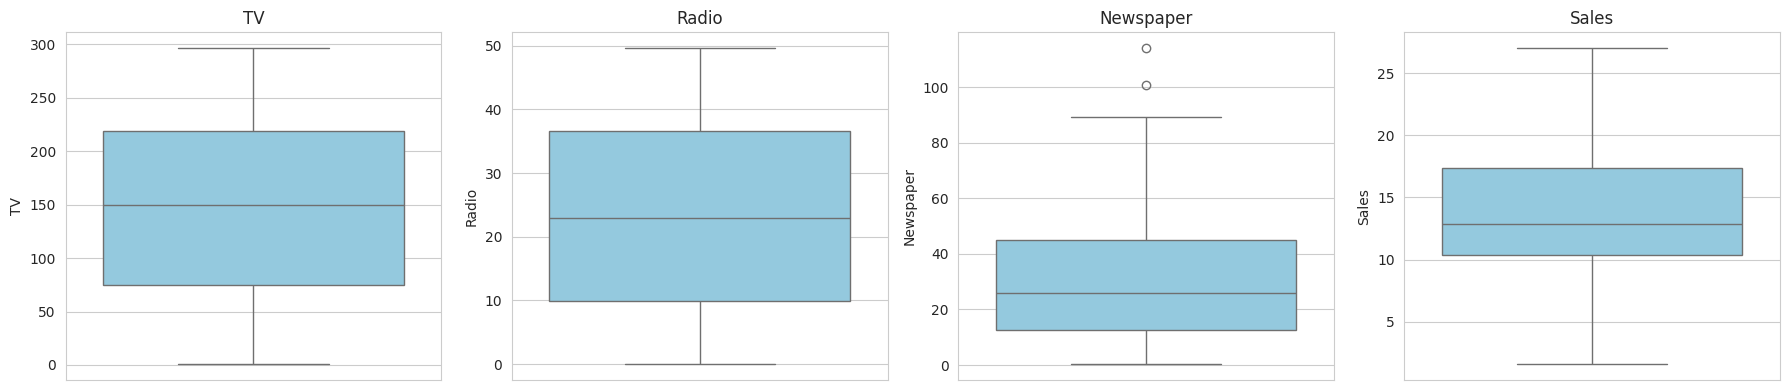

In [6]:

df = df.drop_duplicates()
df = df.dropna()

# Outlier check (boxplot)
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, df.columns):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 4️⃣ Exploratory Data Analysis (EDA)

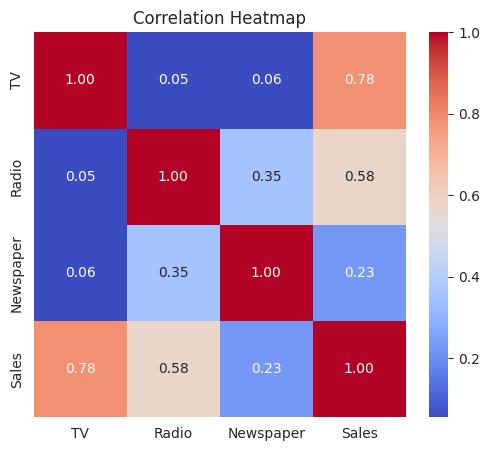

In [7]:
# Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


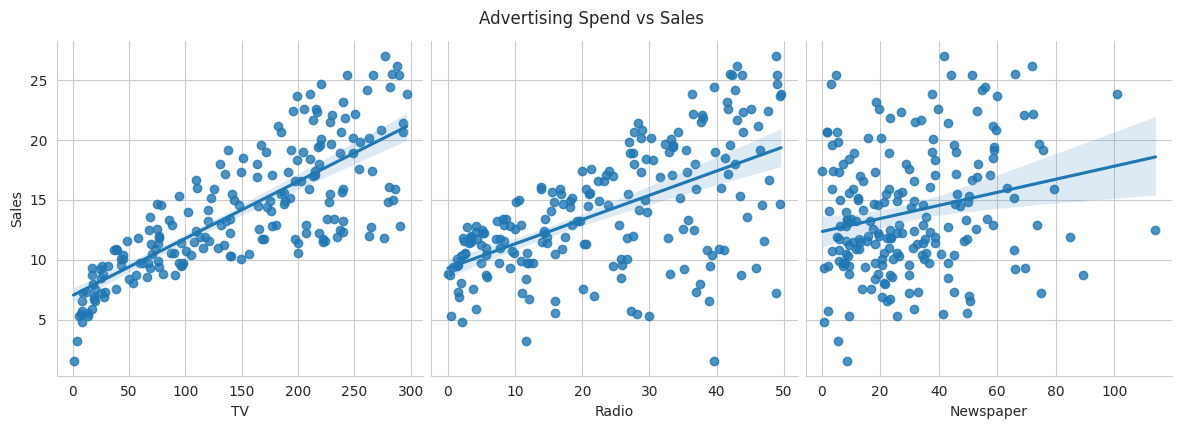

In [8]:
sns.pairplot(df, x_vars=["TV", "Radio", "Newspaper"], y_vars="Sales", height=4, aspect=1, kind="reg")
plt.suptitle("Advertising Spend vs Sales", y=1.05)
plt.show()


## 5️⃣ Feature Engineering

Instead of using only the raw **TV**, **Radio**, and **Newspaper** features, we will create some **additional engineered features** that can improve the model's accuracy:

- `Total_Spend` = TV + Radio + Newspaper
- `TV_Radio_Interaction` = TV × Radio (because the combined effect of TV and Radio advertisements is often stronger than using either channel alone)


In [9]:
df["Total_Spend"] = df["TV"] + df["Radio"] + df["Newspaper"]
df["TV_Radio_Interaction"] = df["TV"] * df["Radio"]

features = ["TV", "Radio", "Newspaper", "Total_Spend", "TV_Radio_Interaction"]
X = df[features]
y = df["Sales"]

X.head()


,TV,Radio,Newspaper,Total_Spend,TV_Radio_Interaction
1,230.1,37.8,69.2,337.1,8697.78
2,44.5,39.3,45.1,128.9,1748.85
3,17.2,45.9,69.3,132.4,789.48
4,151.5,41.3,58.5,251.3,6256.95
5,180.8,10.8,58.4,250.0,1952.64


## 6️⃣ Train-Test Split & Scaling

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (160, 5)  Test shape: (40, 5)


## 7️⃣ Model Training
Compare Four Models-

1. **Linear Regression** (baseline)
2. **Ridge Regression** (regularized linear)
3. **Random Forest Regressor**
4. **XGBoost Regressor** (advanced, gradient boosting based) + **GridSearchCV hyperparameter tuning**


In [11]:
def evaluate(name, y_true, y_pred, results):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    results.append({"Model": name, "R2 Score": round(r2, 4), "MAE": round(mae, 4), "RMSE": round(rmse, 4)})
    print(f"{name} -> R2: {r2:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f}")

results = []


In [12]:
# 1) Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
pred_lr = lr.predict(X_test_scaled)
evaluate("Linear Regression", y_test, pred_lr, results)


Linear Regression -> R2: 0.9742 | MAE: 0.6718 | RMSE: 0.9025


In [13]:
# 2) Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
pred_ridge = ridge.predict(X_test_scaled)
evaluate("Ridge Regression", y_test, pred_ridge, results)


Ridge Regression -> R2: 0.9734 | MAE: 0.6795 | RMSE: 0.9155


In [14]:
# 3) Random Forest Regressor
rf = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
evaluate("Random Forest", y_test, pred_rf, results)


Random Forest -> R2: 0.9886 | MAE: 0.4851 | RMSE: 0.5994


In [15]:
# 4) XGBoost + GridSearchCV hyperparameter tuning (ADVANCED MODEL)
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb = XGBRegressor(random_state=42, objective="reg:squarederror")

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
best_xgb = grid_search.best_estimator_

pred_xgb = best_xgb.predict(X_test)
evaluate("XGBoost (Tuned - Advanced)", y_test, pred_xgb, results)


Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 1.0}
XGBoost (Tuned - Advanced) -> R2: 0.9843 | MAE: 0.5552 | RMSE: 0.7047


## 8️⃣ Model Comparison

In [16]:
results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
results_df


,Model,R2 Score,MAE,RMSE
0,Random Forest,0.9886,0.4851,0.5994
1,XGBoost (Tuned - Advanced),0.9843,0.5552,0.7047
2,Linear Regression,0.9742,0.6718,0.9025
3,Ridge Regression,0.9734,0.6795,0.9155


/tmp/ipykernel_2421/122753156.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="R2 Score", palette="viridis")


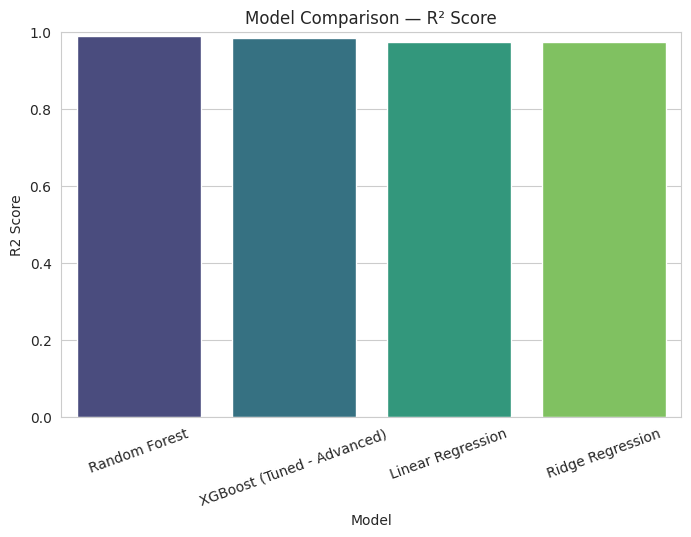

In [17]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x="Model", y="R2 Score", palette="viridis")
plt.xticks(rotation=20)
plt.title("Model Comparison — R² Score")
plt.ylim(0, 1)
plt.show()


## 9️⃣ Feature Importance / Weightage 🎯




In [22]:
importance_rf = rf.feature_importances_
feat_imp_rf = pd.DataFrame({
    "Feature": features,
    "Importance": importance_rf
}).sort_values("Importance", ascending=False).reset_index(drop=True)
feat_imp_rf

,Feature,Importance
0,TV_Radio_Interaction,0.865074
1,Total_Spend,0.068652
2,TV,0.061950
3,Newspaper,0.002615
4,Radio,0.001709


/tmp/ipykernel_2421/3401316478.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp_rf, x="Importance", y="Feature", palette="mako")


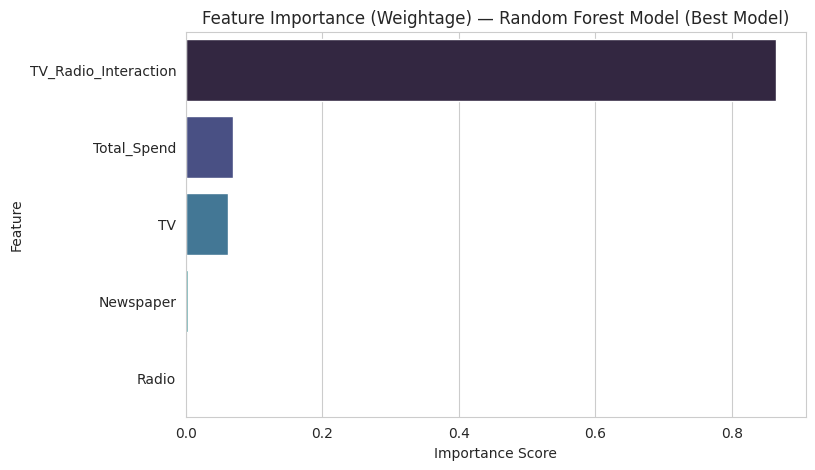

In [26]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feat_imp_rf, x="Importance", y="Feature", palette="mako")
plt.title("Feature Importance (Weightage) — Random Forest Model (Best Model)")
plt.xlabel("Importance Score")
plt.show()

In [28]:
importance_rf = rf.feature_importances_
feat_imp_rf = pd.DataFrame({
    "Feature": features,
    "Importance": importance_rf
}).sort_values("Importance", ascending=False).reset_index(drop=True)

## 🔟 Actual vs Predicted (Best Model)

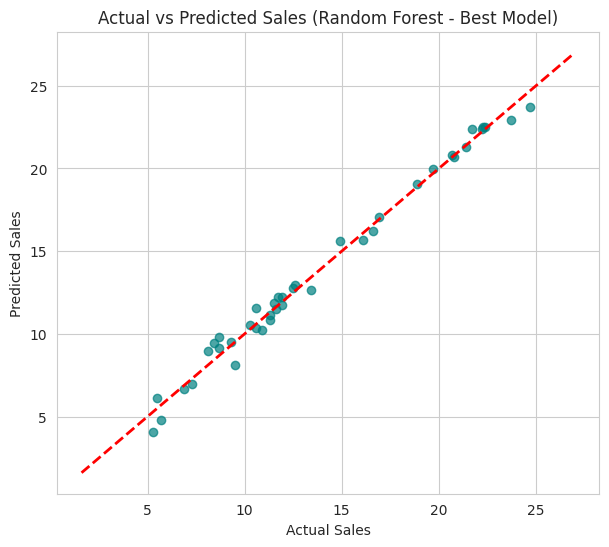

In [29]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, pred_rf, alpha=0.7, color="teal")
plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", lw=2)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest - Best Model)")
plt.show()

In [32]:
import joblib

# Save the trained model
joblib.dump(final_rf, "sales_prediction_model.pkl")

# Download to your PC
from google.colab import files
files.download("sales_prediction_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [33]:
# Load the saved model
loaded_model = joblib.load("sales_prediction_model.pkl")

# Example new data: TV=150, Radio=25, Newspaper=10
new_data = pd.DataFrame({
    "TV": [150],
    "Radio": [25],
    "Newspaper": [10]
})
new_data["Total_Spend"] = new_data["TV"] + new_data["Radio"] + new_data["Newspaper"]
new_data["TV_Radio_Interaction"] = new_data["TV"] * new_data["Radio"]

prediction = loaded_model.predict(new_data[features])
print(f"Predicted Sales: {prediction[0]:.2f}")

Predicted Sales: 15.20
